# Import Libaries

In [29]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 0. Load data

In [2]:
# Download latest version
path = kagglehub.dataset_download(
    "saurabhbadole/bank-customer-churn-prediction-dataset",
    output_dir="data"
)

DATA_DIR = Path(path)
DATASET_FILE = DATA_DIR / "Churn_Modelling.csv"

print("Path to dataset files:", DATASET_FILE)

Path to dataset files: data\Churn_Modelling.csv


# 1. Data inspection

In [3]:
df = pd.read_csv(DATASET_FILE)

print("Data shape:", df.shape)
print()
print(df.head())

Data shape: (10000, 14)

   RowNumber  CustomerId   Surname  ...  IsActiveMember EstimatedSalary Exited
0          1    15634602  Hargrave  ...               1       101348.88      1
1          2    15647311      Hill  ...               1       112542.58      0
2          3    15619304      Onio  ...               0       113931.57      1
3          4    15701354      Boni  ...               0        93826.63      0
4          5    15737888  Mitchell  ...               1        79084.10      0

[5 rows x 14 columns]


### Info
The dataset contains 10,000 customers and 14 columns. It includes numerical and categorical features describing customer characteristics and banking activity. The target variable is `Exited`, which indicates whether a customer left the bank. Some columns, such as `RowNumber` and `CustomerId`, are identifiers and will be removed during preprocessing.

In [4]:
print("Columns information (null values and dtypes):")
print(df.info())
print()
print(df[["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "HasCrCard", "IsActiveMember"]].describe())

Columns information (null values and dtypes):
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB
None

        CreditScore           Age  ...    HasCrCard  IsAc

### Info
The dataset does not contain any null values. There are several numerical features, such as `Balance`, `CreditScore`, `Age`, and `EstimatedSalary`. The features have different ranges, so some of them may require standardization before training certain machine learning models. We will also check for potential outliers during the data analysis.

# 2. Evaluate data analysis

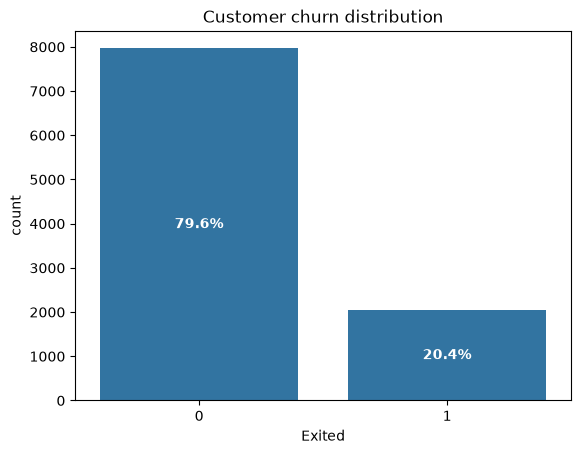

In [5]:
ax = sns.countplot(
    df,
    x="Exited"
)

total = len(df)

for container in ax.containers:

    labels= [
        f"{(bar.get_height() / total) * 100:.1f}%" 
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontweight="bold"
    )
    

plt.title("Customer churn distribution")
plt.show()

### Observation
As we can see, roughly **20%** of customers leave the bank, while approximately **80%** remain.

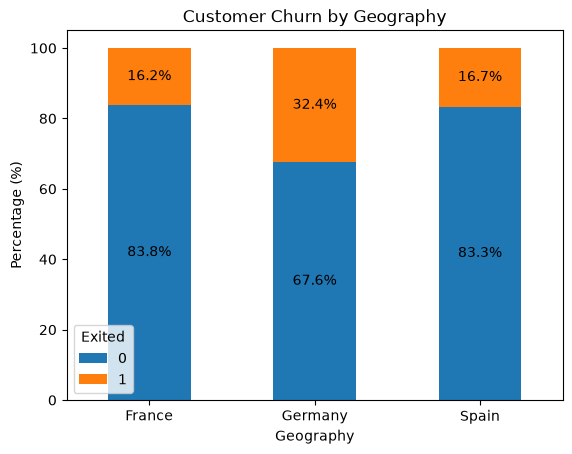

In [6]:
geo_churn = pd.crosstab(df["Geography"], df["Exited"], normalize="index") * 100

ax = geo_churn.plot(
    kind="bar",
    stacked=True
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() > 5 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center"
    )

plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Percentage (%)")
plt.legend(title="Exited")
plt.xticks(rotation=0)

plt.show()

### Observation
There is a significant difference in churn rates between Germany and the other countries. Around **32.5%** of German customers exited the bank, compared to approximately **16.5%** of customers from France and Spain.

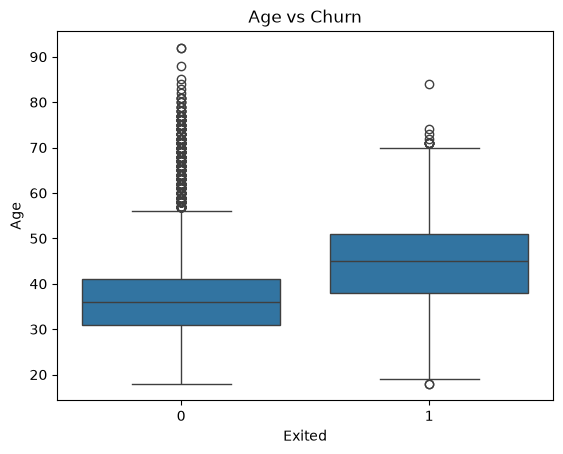

In [7]:
sns.boxplot(data=df, x="Exited", y="Age")
plt.title("Age vs Churn")
plt.show()

### Observation
Customers who exited the bank tend to be older than customers who stayed. The median age is noticeably higher for customers who churned, suggesting that age may be an important factor related to customer churn.

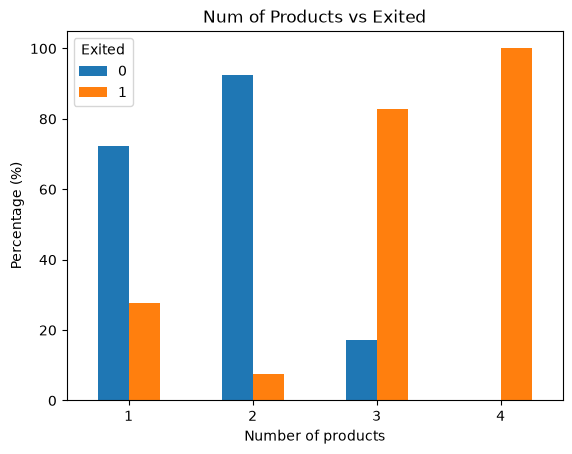

In [8]:
product_churn = pd.crosstab(
    df["NumOfProducts"],
    df["Exited"],
    normalize="index"
) * 100

ax = product_churn.plot(
    kind="bar"
)

plt.xlabel("Number of products")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.title("Num of Products vs Exited")
plt.show()

### Observation
Customers with **3** or **4** products have a significantly higher churn rate than customers with 1 or 2 products. In contrast, customers with **2** product have the lowest churn rate.

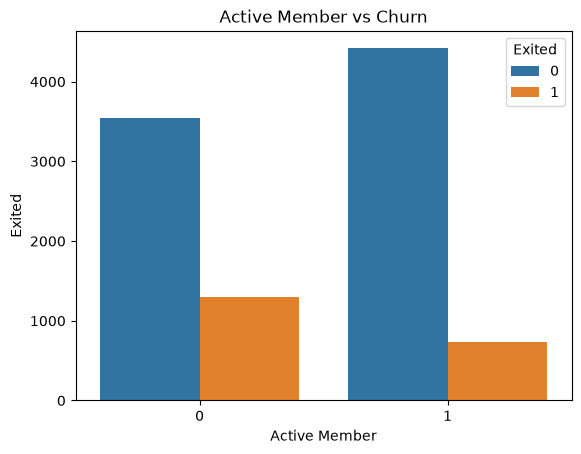

In [9]:
sns.countplot(data=df, x="IsActiveMember", hue="Exited")
plt.title("Active Member vs Churn")
plt.xlabel("Active Member")
plt.ylabel("Exited")
plt.show()

### Observation
Active members have a lower churn rate compared to inactive members. This suggests that customers who actively use the bank's services are less likely to leave.

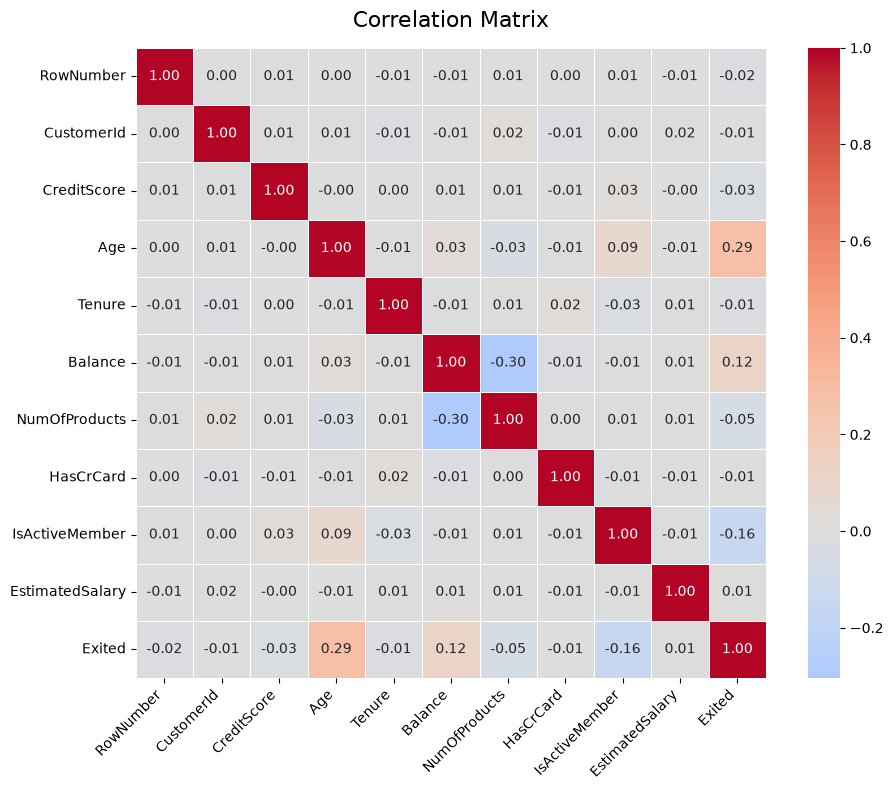

In [10]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix", fontsize=16, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation
`Age` has the strongest positive correlation with customer churn, followed by `Balance`. In contrast, being an `Active Member` has the strongest negative correlation with churn, indicating that active customers are less likely to leave.

# 3. Data Preprocessing

## 3.1 Remove unnecessary columns

In [11]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3.2 Encoding categorical columns

In [12]:
df = pd.get_dummies(
    df,
    ["Geography", "Gender"],
    dtype=int,
    drop_first=True
)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


## 3.3 Create X and y Data Frames

In [13]:
X = df.drop(columns="Exited")
y = df["Exited"]

print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


# 4. Train/Test split

## 4.1 Split the data

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 11)
X_test: (2000, 11)
y_train: (8000,)
y_test: (2000,)


## 4.2 Scal the data

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[0], X_test_scaled[0]

(array([ 1.058568  ,  1.71508648,  0.68472287, -1.22605881, -0.91025649,
         0.64104192, -1.030206  ,  1.04208392, -0.57831252, -0.57773517,
         0.90750738]),
 array([-0.68073539, -0.27993196,  0.68472287, -1.22605881,  0.80883036,
         0.64104192, -1.030206  , -0.09502138, -0.57831252, -0.57773517,
         0.90750738]))

# 5. Logistic Regression

## 5.1 Create and train the model

In [16]:
# Create a model
model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

## 5.2 Test the model

In [17]:
# Test the model
y_pred = model.predict(X_test_scaled)

print(f"Accuracy: {(accuracy_score(y_test, y_pred) * 100):.2f}%")
print(f"Precision: {(precision_score(y_test, y_pred) * 100):.2f}%")
print(f"Recall: {(recall_score(y_test, y_pred) * 100):.2f}%")
print(f"F1-score: {(f1_score(y_test, y_pred) * 100):.2f}%")

Accuracy: 80.80%
Precision: 58.91%
Recall: 18.67%
F1-score: 28.36%


### Observation
The model achieved **80.80%** accuracy. Precision of **58.91%** means that over half of predicted churn cases were correct, while the low Recall of **18.67%** shows that the model missed many customers who actually churned. The F1-score of **28.36%** confirms that the overall balance between Precision and Recall is relatively weak.

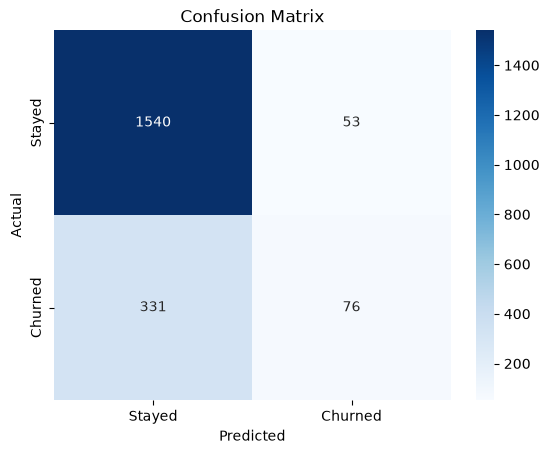

In [18]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Observation
The model predicted most customers as staying with the bank. This resulted in many correctly classified customers who stayed, but also many churned customers being incorrectly classified as staying.

# 6. Decision Tree

## 6.1 Create a model

In [ ]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

## 6.2 Test the model

In [27]:
# Test the model
y_pred_tree = tree_model.predict(X_test)

print(f"Accuracy: {(accuracy_score(y_test, y_pred_tree) * 100):.2f}%")
print(f"Precision: {(precision_score(y_test, y_pred_tree) * 100):.2f}%")
print(f"Recall: {(recall_score(y_test, y_pred_tree) * 100):.2f}%")
print(f"F1-score: {(f1_score(y_test, y_pred_tree) * 100):.2f}%")

Accuracy: 78.30%
Precision: 46.95%
Recall: 51.11%
F1-score: 48.94%


### Observation
The Decision Tree model achieved lower `Accuracy` and `Precision` compared to Logistic Regression, but it achieved higher `Recall` and `F1-score`. This shows that the tree was better at identifying customers who actually churned instead of classifying most customers as staying.

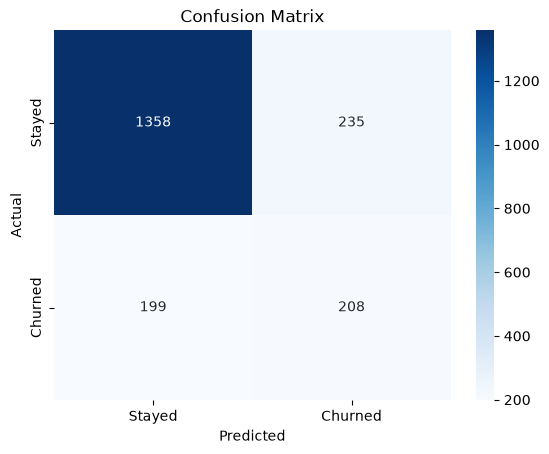

In [28]:
cm = confusion_matrix(y_test, y_pred_tree)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Observation
The confusion matrices clearly show the difference between the two models. Logistic Regression classified most customers as staying, while the Decision Tree identified more churned customers. Although the Decision Tree performed better in detecting churn, its results are still not very strong, with an `F1-score` of only around **50%**.

# 7. Random Forest

## 7.1 Create a model

In [30]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_train)

## 7.2 Test the model

In [32]:
y_pred_rf = rf_model.predict(X_test)

print(f"Accuracy: {(accuracy_score(y_test, y_pred_rf) * 100):.2f}%")
print(f"Precision: {(precision_score(y_test, y_pred_rf) * 100):.2f}%")
print(f"Recall: {(recall_score(y_test, y_pred_rf) * 100):.2f}%")
print(f"F1-score: {(f1_score(y_test, y_pred_rf) * 100):.2f}%")

Accuracy: 86.45%
Precision: 78.33%
Recall: 46.19%
F1-score: 58.11%


### Observation
The Random Forest model performed better than the two previous models in almost every category. It achieved higher `Accuracy` and `Precision`, while its `Recall` was slightly lower than the Decision Tree. The model also achieved an `F1-score` around **10% higher** than the Decision Tree, making it the strongest model so far.

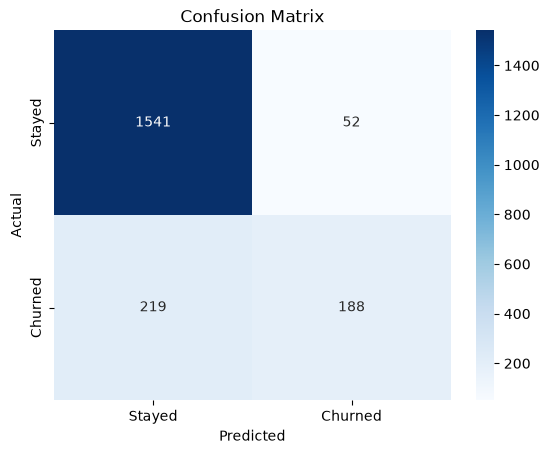

In [33]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Observation
The main difference can be seen in the number of customers who stayed and were correctly classified. However, the model still has difficulties identifying customers who actually churned, resulting in a relatively high number of false negatives.